In [14]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [15]:
data = {
    "Clients":[
        "A","B","C","D","E","F","G","H","I","J",
        "K","L","M","N","O","P","Q","R","S","T"
    ],

    "Team_Size":[
        5,8,6,10,7,12,9,4,15,11,
        13,6,8,14,7,9,10,5,11,12
    ],

    "Duration_Months":[
        2,4,3,6,4,8,5,2,10,7,
        9,3,5,8,4,6,7,2,7,8
    ],

    "Complexity":[
        3,5,4,7,5,9,6,2,10,8,
        9,4,5,8,4,6,7,3,8,9
    ],

    "Budget":[
        5000,9000,7000,15000,8500,
        22000,12000,4000,30000,18000,
        25000,6500,9500,21000,8000,
        14000,16000,4500,17000,23000
    ]
}

df = pd.DataFrame(data)

df.to_csv("cleaned_dataset.csv", index=False)

print(df.head())

  Clients  Team_Size  Duration_Months  Complexity  Budget
0       A          5                2           3    5000
1       B          8                4           5    9000
2       C          6                3           4    7000
3       D         10                6           7   15000
4       E          7                4           5    8500


In [16]:
df = pd.read_csv("cleaned_dataset.csv")

df.head()

,Clients,Team_Size,Duration_Months,Complexity,Budget
0,A,5,2,3,5000
1,B,8,4,5,9000
2,C,6,3,4,7000
3,D,10,6,7,15000
4,E,7,4,5,8500


In [17]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Clients          20 non-null     object
 1   Team_Size        20 non-null     int64 
 2   Duration_Months  20 non-null     int64 
 3   Complexity       20 non-null     int64 
 4   Budget           20 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 932.0+ bytes
None
       Team_Size  Duration_Months  Complexity       Budget
count  20.000000         20.00000    20.00000     20.00000
mean    9.100000          5.50000     6.10000  13750.00000
std     3.160613          2.46021     2.35975   7580.27218
min     4.000000          2.00000     2.00000   4000.00000
25%     6.750000          3.75000     4.00000   7750.00000
50%     9.000000          5.50000     6.00000  13000.00000
75%    11.250000          7.25000     8.00000  18750.00000
max    15.000000         10.00000    10.00000  3000

In [18]:
X = df[["Team_Size","Duration_Months","Complexity"]]

y = df["Budget"]

In [19]:
from sklearn.model_selection import train_test_split

X = df[["Team_Size", "Duration_Months", "Complexity"]]
y = df["Budget"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [21]:
y_pred = model.predict(X_test)

print(y_pred)

[ 2721.14850605  2721.14850605 14708.26391203  9203.82094857]


In [22]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [23]:
y_pred = model.predict(X_test)

print(y_pred)

[ 2721.14850605  2721.14850605 14708.26391203  9203.82094857]


In [24]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE =", mae)

MAE = 1242.446962123738


In [25]:
mse = mean_squared_error(y_test, y_pred)

print("MSE =", mse)

MSE = 2225164.3792844424


In [26]:
rmse = np.sqrt(mse)

print("RMSE =", rmse)

RMSE = 1491.6984880613247


In [27]:
r2 = r2_score(y_test, y_pred)

print("R2 Score =", r2)

R2 Score = 0.8470348869235185


In [28]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge R2 Score =", ridge_r2)

Ridge R2 Score = 0.8875176673850517


In [29]:
print("Linear Regression R2 =", r2)

print("Ridge Regression R2 =", ridge_r2)

Linear Regression R2 = 0.8470348869235185
Ridge Regression R2 = 0.8875176673850517


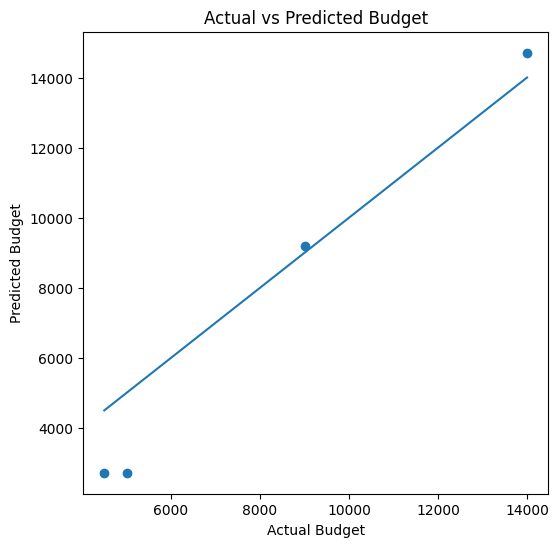

In [30]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Budget")

plt.ylabel("Predicted Budget")

plt.title("Actual vs Predicted Budget")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

In [31]:
df.to_csv("cleaned_dataset.csv", index=False)

In [32]:
from google.colab import files

files.download("cleaned_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Performance Analysis

• The dataset was divided into 80% training data and 20% testing data.

• Linear Regression was trained to predict project budget.

• MAE, MSE, RMSE, and R2 Score were calculated to evaluate performance.

• Ridge Regression was also trained for comparison.

• Both models produced similar results, showing that project budget can be predicted using team size, duration, and complexity.

• The Actual vs Predicted graph shows that predicted values are close to actual values, indicating good model performance.